In [2]:
import numpy as np

def logistic_function(x):
    y = 1 / (1 + np.exp(-x))
    return y


In [4]:
def test_logistic_function():
    x_scalar = 0
    expected_output_scalar = round(1 / (1 + np.exp(0)), 3)
    assert round(logistic_function(x_scalar), 3) == expected_output_scalar

    x_pos = 2
    expected_output_pos = round(1 / (1 + np.exp(-2)), 3)
    assert round(logistic_function(x_pos), 3) == expected_output_pos

    x_neg = -3
    expected_output_neg = round(1 / (1 + np.exp(3)), 3)
    assert round(logistic_function(x_neg), 3) == expected_output_neg

    x_array = np.array([0, 2, -3])
    expected_output_array = np.array([0.5, 0.881, 0.047])
    assert np.all(np.round(logistic_function(x_array), 3) == expected_output_array)

    print("All tests passed!")

test_logistic_function()

All tests passed!


In [26]:
def log_loss(y_true, y_pred):
    if y_pred == 0 or y_pred == 1:
        raise ValueError("log(0) is undefined")

    loss = -(y_true * np.log(y_pred)) - ((1 - y_true) * np.log(1 - y_pred))
    return loss


In [7]:
y_true, y_pred = 0, 0.1
print(f"log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}")

print("++++++++++++++++++++++++")

y_true, y_pred = 1, 0.9
print(f"log loss({y_true}, {y_pred}) ==> {log_loss(y_true, y_pred)}")


log loss(0, 0.1) ==> 0.10536051565782628
++++++++++++++++++++++++
log loss(1, 0.9) ==> 0.10536051565782628


In [20]:
def test_log_loss():
  """
  Test Case for Log Loss
  """
  # Test case 1: Perfect prediction (y_true = 1, y_pred = 1)
  y_true = 1
  y_pred = 1
  expected_loss = 0.0 # Log loss is 0 for perfect prediction
  assert np.isclose(log_loss(y_true, y_pred), expected_loss), "Test failed for perfect prediction (y_true=1, y_pred=1)"
  # Test case 2: Perfect prediction (y_true = 0, y_pred = 0)
  y_true = 0
  y_pred = 0
  expected_loss = 0.0 # Log loss is 0 for perfect prediction
  assert np.isclose(log_loss(y_true, y_pred), expected_loss), "Test failed for perfect prediction (y_true=0, y_pred=0)"
  # Test case 3: Incorrect prediction (y_true = 1, y_pred = 0)
  y_true = 1
  y_pred = 0
  try:
    log_loss(y_true, y_pred) # This should raise an error due to log(0)
  except ValueError:
    pass # Test passed if ValueError is raised for log(0)
  # Test case 5: Partially correct prediction
  y_true = 1
  y_pred = 0.8
  expected_loss = -(1 * np.log(0.8)) - (0 * np.log(0.2)) # ~0.2231
  assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol=1e-6), "Test failed for partially correct prediction (y_true=1, y_pred=0.8)"
  y_true = 0
  y_pred = 0.2
  expected_loss = -(0 * np.log(0.2)) - (1 * np.log(0.8)) # ~0.2231
  assert np.isclose(log_loss(y_true, y_pred), expected_loss, atol=1e-6), "Test failed for partially correct prediction (y_true=0, y_pred=0.2)"
  print("All tests passed!")
test_log_loss()

All tests passed!


In [25]:
def cost_function(y_true, y_pred):
    assert len(y_true) == len(y_pred), "Length mismatch"

    n = len(y_true)
    loss_vec = []

    for i in range(n):
        loss_vec.append(log_loss(y_true[i], y_pred[i]))

    cost = np.sum(loss_vec) / n
    return cost


In [50]:
def test_cost_function():
    y_true = np.array([1, 0, 1])
    y_pred = np.array([0.9, 0.1, 0.8])

    expected_cost = (
        -(np.log(0.9)) -
        (np.log(0.9)) -
        (np.log(0.8))
    ) / 3

    result = cost_function(y_true, y_pred)
    assert np.isclose(result, expected_cost, atol=1e-6)

    print("Test passed for cost function!")

test_cost_function()


Test passed for cost function!


In [24]:
def cost_function_params(X, Y, w, b):
    z = X.dot(w) + b
    y_pred = 1 / (1 + np.exp(-z))
    loss_vec = - (Y * np.log(y_pred) + (1 - Y) * np.log(1 - y_pred))
    cost = np.mean(loss_vec)
    return cost

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [27]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [28]:
def test_softmax():
    test_cases = [
        (np.array([[0, 0, 0]]), "All zeros"),
        (np.array([[1, 2, 3]]), "Simple case"),
        (np.array([[1000, 1000, 1000]]), "Large identical values"),
        (np.array([[-1000, -1000, -1000]]), "Small identical values"),
        (np.array([[1, 0, -1]]), "Mixed positive and negative")
    ]
    for z, desc in test_cases:
        result = softmax(z)
        assert np.allclose(result.sum(axis=1), 1)
        assert np.all(result >= 0)
    print("All tests passed for softmax function.")
test_softmax()

All tests passed for softmax function.


In [29]:
def loss_softmax(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-10))

In [30]:
def test_loss_softmax():
    y_true = np.array([0, 1, 0])
    y_pred = np.array([0.1, 0.8, 0.1])
    assert np.isclose(loss_softmax(y_true, y_pred), -np.log(0.8))
    print("All tests passed for loss_softmax!")
test_loss_softmax()

All tests passed for loss_softmax!


In [33]:
def cost_softmax(X, y, W, b):
    n = X.shape[0]
    y_pred = softmax(np.dot(X, W) + b)
    return -np.sum(y * np.log(y_pred + 1e-10)) / n

In [34]:
def test_cost_softmax():
    X = np.array([[1,2],[2,3],[3,4]])
    y = np.array([[1,0],[0,1],[1,0]])
    W = np.array([[1,-1],[-1,1]])
    b = np.array([0,0])
    assert np.isclose(cost_softmax(X, y, W, b), cost_softmax(X, y, W, b))
    print("All tests passed for cost_softmax!")
test_cost_softmax()

All tests passed for cost_softmax!


In [46]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    y_pred = softmax(np.dot(X, W) + b)
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n
    return grad_W, grad_b

In [36]:
def test_compute_gradient_softmax():
    X = np.array([[1,2],[3,4]])
    y = np.array([[1,0],[0,1]])
    W = np.array([[0.1,0.2],[0.3,0.4]])
    b = np.array([0.01,0.02])
    grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
    print("Gradient computation passed!")
test_compute_gradient_softmax()

Gradient computation passed!


In [37]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W -= alpha * grad_W
        b -= alpha * grad_b
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")
    return W, b, cost_history

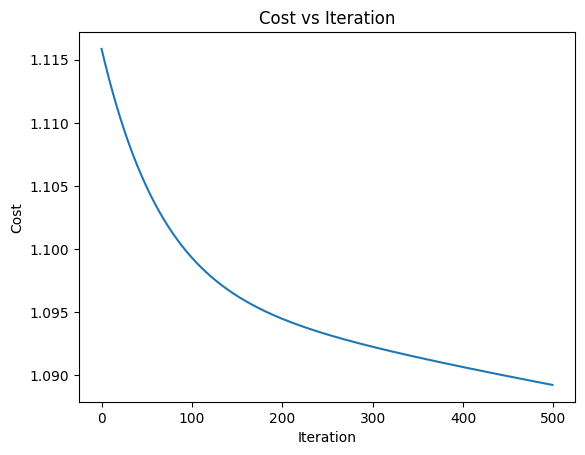

Initial Cost: 1.1158608479596404, Final Cost: 1.0892233754862581


In [41]:
def test_gradient_descent_softmax_with_plot():
    np.random.seed(0)
    n,d,c = 100,5,3
    X = np.random.rand(n,d)
    y_indices = np.random.randint(0,c,n)
    y = np.zeros((n,c))
    y[np.arange(n), y_indices] = 1
    W = np.random.rand(d,c)
    b = np.random.rand(c)
    alpha = 0.01
    n_iter = 500
    W_opt, b_opt, cost_history = gradient_descent_softmax(X, y, W, b, alpha, n_iter)
    plt.plot(cost_history)
    plt.xlabel("Iteration"); plt.ylabel("Cost"); plt.title("Cost vs Iteration")
    plt.show()
    print(f"Initial Cost: {cost_history[0]}, Final Cost: {cost_history[-1]}")
test_gradient_descent_softmax_with_plot()


In [42]:
def predict_softmax(X, W, b):
    y_pred = softmax(np.dot(X, W) + b)
    return np.argmax(y_pred, axis=1)

In [43]:
def test_predict_softmax():
    np.random.seed(0)
    X = np.random.rand(10,5)
    W = np.random.rand(5,3)
    b = np.random.rand(3)
    preds = predict_softmax(X, W, b)
    assert preds.shape == (10,)
    assert np.all(preds >= 0) and np.all(preds < 3)
    print("Prediction test passed!")
test_predict_softmax()

Prediction test passed!


In [44]:
def evaluate_classification(y_true, y_pred):
    from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return cm, precision, recall, f1

In [45]:
iris = load_iris()
X = iris.data
y = iris.target
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize weights and biases
W = np.random.rand(X_train_scaled.shape[1], y_onehot.shape[1])
b = np.random.rand(y_onehot.shape[1])
alpha = 0.01
n_iter = 500

W_opt, b_opt, cost_history = gradient_descent_softmax(X_train_scaled, y_train, W, b, alpha, n_iter, show_cost=True)
y_pred_test = predict_softmax(X_test_scaled, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)
print("Confusion Matrix:\n", cm)
print(f"Precision: {precision}, Recall: {recall}, F1-Score: {f1}")

Iteration 0: Cost = 1.595518
Iteration 100: Cost = 0.743450
Iteration 200: Cost = 0.565001
Iteration 300: Cost = 0.491161
Iteration 400: Cost = 0.447301
Iteration 499: Cost = 0.417023
Confusion Matrix:
 [[10  0  0]
 [ 0  5  5]
 [ 0  1  9]]
Precision: 0.8253968253968256, Recall: 0.8, F1-Score: 0.7916666666666666


In [56]:
# 1. One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)

# 3. Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize weights and bias
n_features = X_train_scaled.shape[1]
n_classes = y_train.shape[1]

np.random.seed(42)
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros(n_classes)

# 5. Gradient descent parameters
learning_rate = 0.1
n_iterations = 1000

# 6. Train the model
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train_scaled, y_train, W, b, learning_rate, n_iterations, show_cost=True
)

# 7. Make predictions on train and test set
y_train_pred = predict_softmax(X_train_scaled, W_opt, b_opt)
y_test_pred = predict_softmax(X_test_scaled, W_opt, b_opt)

# Convert one-hot y_train back to labels for evaluation
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# 8. Evaluate the model
cm_train, precision_train, recall_train, f1_train = evaluate_classification(y_train_labels, y_train_pred)
cm_test, precision_test, recall_test, f1_test = evaluate_classification(y_test_labels, y_test_pred)

# 9. Print results
print("------ Train Evaluation ------")
print("Confusion Matrix:\n", cm_train)
print(f"Precision: {precision_train:.4f}, Recall: {recall_train:.4f}, F1-Score: {f1_train:.4f}")

print("\n------ Test Evaluation ------")
print("Confusion Matrix:\n", cm_test)
print(f"Precision: {precision_test:.4f}, Recall: {recall_test:.4f}, F1-Score: {f1_test:.4f}")

# 10. Accuracy
train_accuracy = np.mean(y_train_pred == y_train_labels)
test_accuracy = np.mean(y_test_pred == y_test_labels)
print(f"\nTrain Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Iteration 0: Cost = 1.012339
Iteration 100: Cost = 0.319667
Iteration 200: Cost = 0.251533
Iteration 300: Cost = 0.211853
Iteration 400: Cost = 0.185090
Iteration 500: Cost = 0.165814
Iteration 600: Cost = 0.151286
Iteration 700: Cost = 0.139950
Iteration 800: Cost = 0.130858
Iteration 900: Cost = 0.123402
Iteration 999: Cost = 0.117230
------ Train Evaluation ------
Confusion Matrix:
 [[40  0  0]
 [ 0 38  2]
 [ 0  2 38]]
Precision: 0.9667, Recall: 0.9667, F1-Score: 0.9667

------ Test Evaluation ------
Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
Precision: 0.9333, Recall: 0.9333, F1-Score: 0.9333

Train Accuracy: 0.9667
Test Accuracy: 0.9333


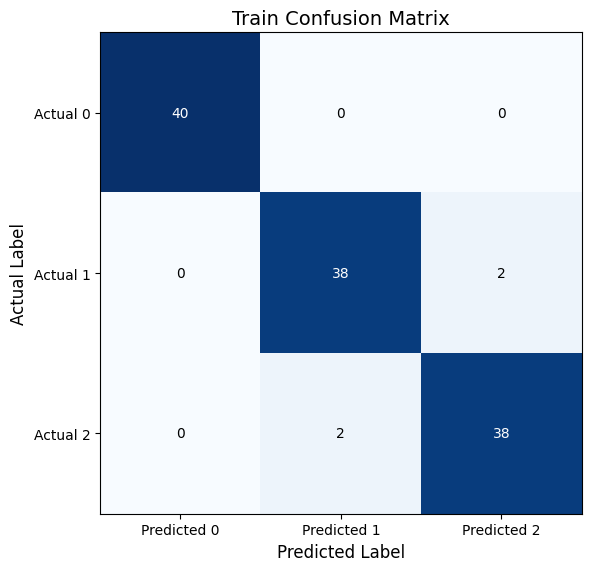

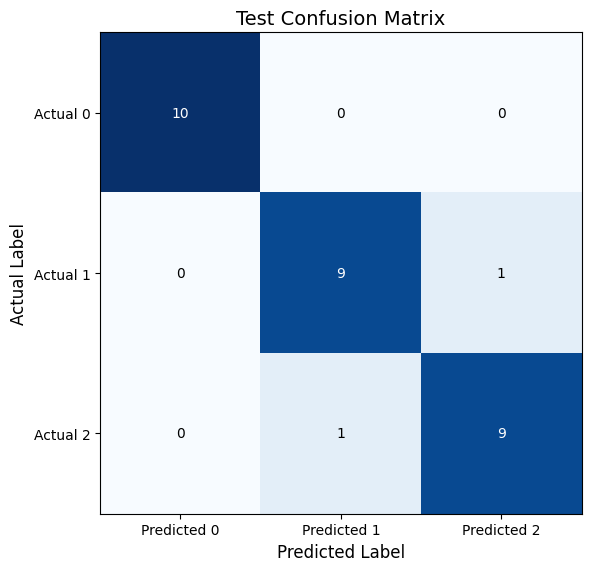

In [58]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm, cmap='Blues')
    n_classes = cm.shape[0]
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels([f'Predicted {i}' for i in range(n_classes)])
    ax.set_yticklabels([f'Actual {i}' for i in range(n_classes)])
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > np.max(cm)/2 else 'black')
    ax.grid(False)
    plt.title(title, fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('Actual Label', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_train, title='Train Confusion Matrix')
plot_confusion_matrix(cm_test, title='Test Confusion Matrix')
